# Evaluasi Klasterisasi FCM

Notebook ini mengevaluasi kualitas klasterisasi dengan Partition Coefficient, membandingkan prediksi tindakan dengan tindakan aktual, dan menghasilkan seluruh visualisasi yang sudah ada pada folder `outputs`.

In [4]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import mpltern  # noqa: F401
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

ROOT_DIR = Path.cwd()
OUTPUT_DIR = ROOT_DIR / "outputs"
ARTIFACT_DIR = OUTPUT_DIR / "artifacts"
EVALUATION_DIR = OUTPUT_DIR / "evaluasi"
EVALUATION_DIR.mkdir(exist_ok=True)

FEATURE_COLUMNS = [
    "Usia Ibu",
    "Usia Kehamilan",
    "Gravida",
    "Tekanan Darah",
    "Denyut Jantung Janin",
    "Nilai AFI",
    "Kejadian KPD",
]
CLUSTER_LABELS = ["Mild", "Moderate", "Severe"]
CLUSTER_COLORS = {
    "Mild": "#40DF00",
    "Moderate": "#FF9800",
    "Severe": "#F44336",
}

mpl.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.labelsize": 10,
        "figure.dpi": 150,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

In [ ]:
def interpret_pc(value):
    if value >= 0.80:
        return "Sangat Baik"
    if value >= 0.60:
        return "Baik"
    if value >= 0.40:
        return "Cukup"
    return "Buruk"


def clean_action_text(value):
    text = str(value or "").strip().lower()
    text = text.replace("  ", " ").replace(", ", ",")
    parts = [part.strip() for part in text.replace("+", ",").split(",")]
    parts = [part for part in parts if part and part != "mow"]
    text = ",".join(parts)
    return text


def summarize_prediction(value):
    return clean_action_text(value)


def classify_alignment(cluster_label, actual_action):
    actual = clean_action_text(actual_action)
    if not actual:
        return "Perlu Review"

    is_surgical = any(keyword in actual for keyword in ["sc", "sctp", "sectio", "cito", "od,sc", "od, sc"])
    is_vaginal = any(keyword in actual for keyword in ["partus", "spontan", "pervaginam", "normal"])

    if cluster_label == "Mild":
        return "Selaras" if is_vaginal else "Perlu Review"
    return "Selaras" if is_surgical else "Perlu Review"


def save_matplotlib_figure(path):
    plt.savefig(path)
    if mpl.get_backend().lower() != "agg":
        plt.show()
    plt.close()


def read_output_csv(path):
    encodings = ["utf-8-sig", "utf-8", "cp1252", "latin1"]
    last_error = None
    for encoding in encodings:
        try:
            return pd.read_csv(path, sep=None, engine="python", encoding=encoding)
        except UnicodeDecodeError as error:
            last_error = error
    raise last_error


def show_plotly_figure(fig):
    try:
        fig.show()
    except Exception as error:
        if "nbformat" not in str(error) and "Mime type rendering" not in str(error):
            raise


def catmull_rom_smooth(x_values, y_values, samples_per_segment=30):
    points = np.column_stack([x_values, y_values]).astype(float)
    if len(points) < 4:
        return np.array(x_values, dtype=float), np.array(y_values, dtype=float)

    padded = np.vstack([points[0], points, points[-1]])
    smooth_points = []

    for index in range(1, len(padded) - 2):
        p0, p1, p2, p3 = padded[index - 1], padded[index], padded[index + 1], padded[index + 2]
        t_values = np.linspace(0, 1, samples_per_segment, endpoint=False)
        for t in t_values:
            t2 = t * t
            t3 = t2 * t
            point = 0.5 * (
                (2 * p1)
                + (-p0 + p2) * t
                + (2 * p0 - 5 * p1 + 4 * p2 - p3) * t2
                + (-p0 + 3 * p1 - 3 * p2 + p3) * t3
            )
            smooth_points.append(point)

    smooth_points.append(points[-1])
    smooth_points = np.array(smooth_points)
    return smooth_points[:, 0], smooth_points[:, 1]

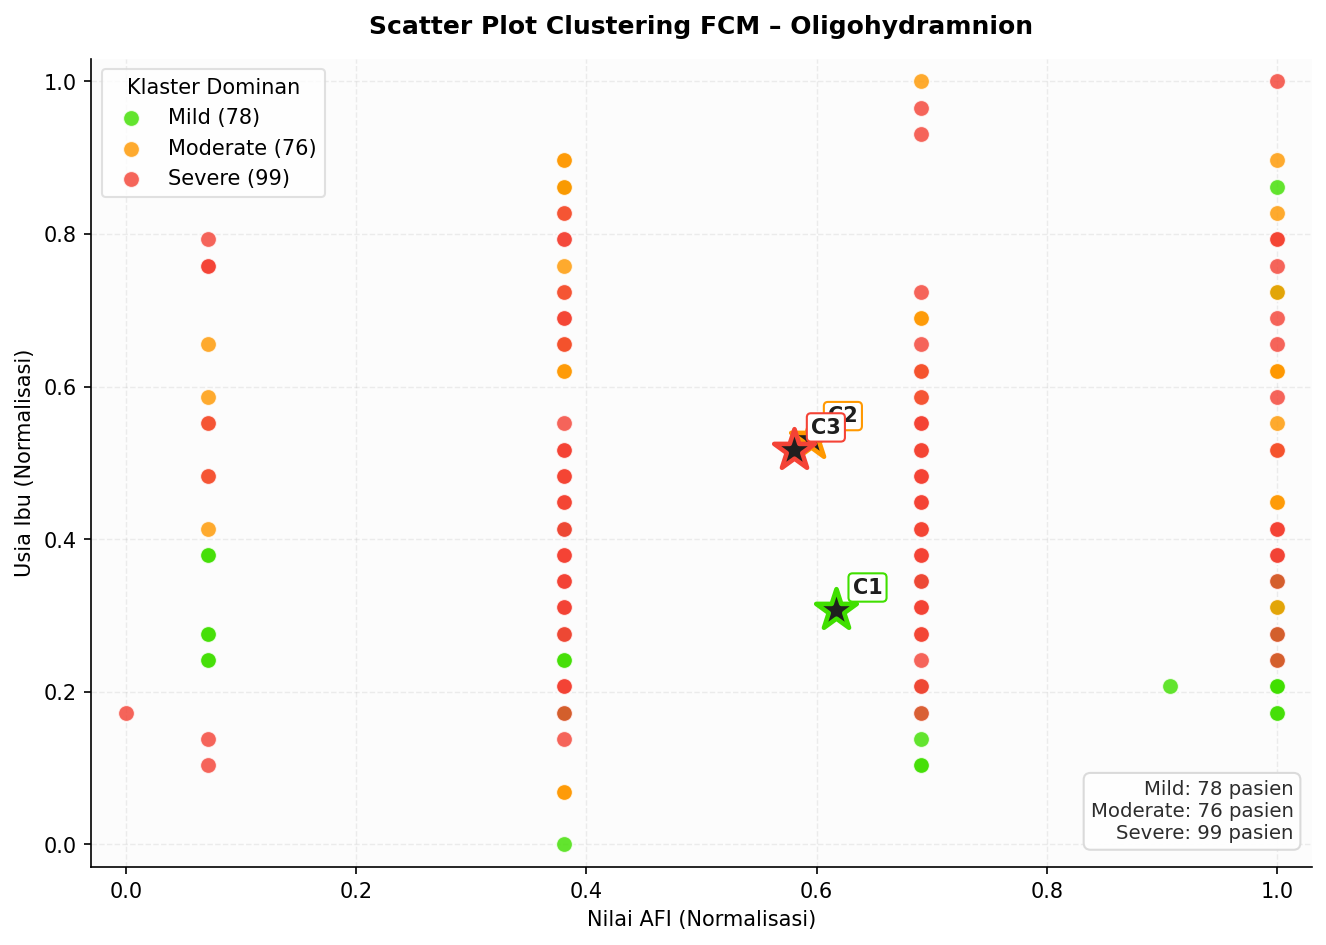

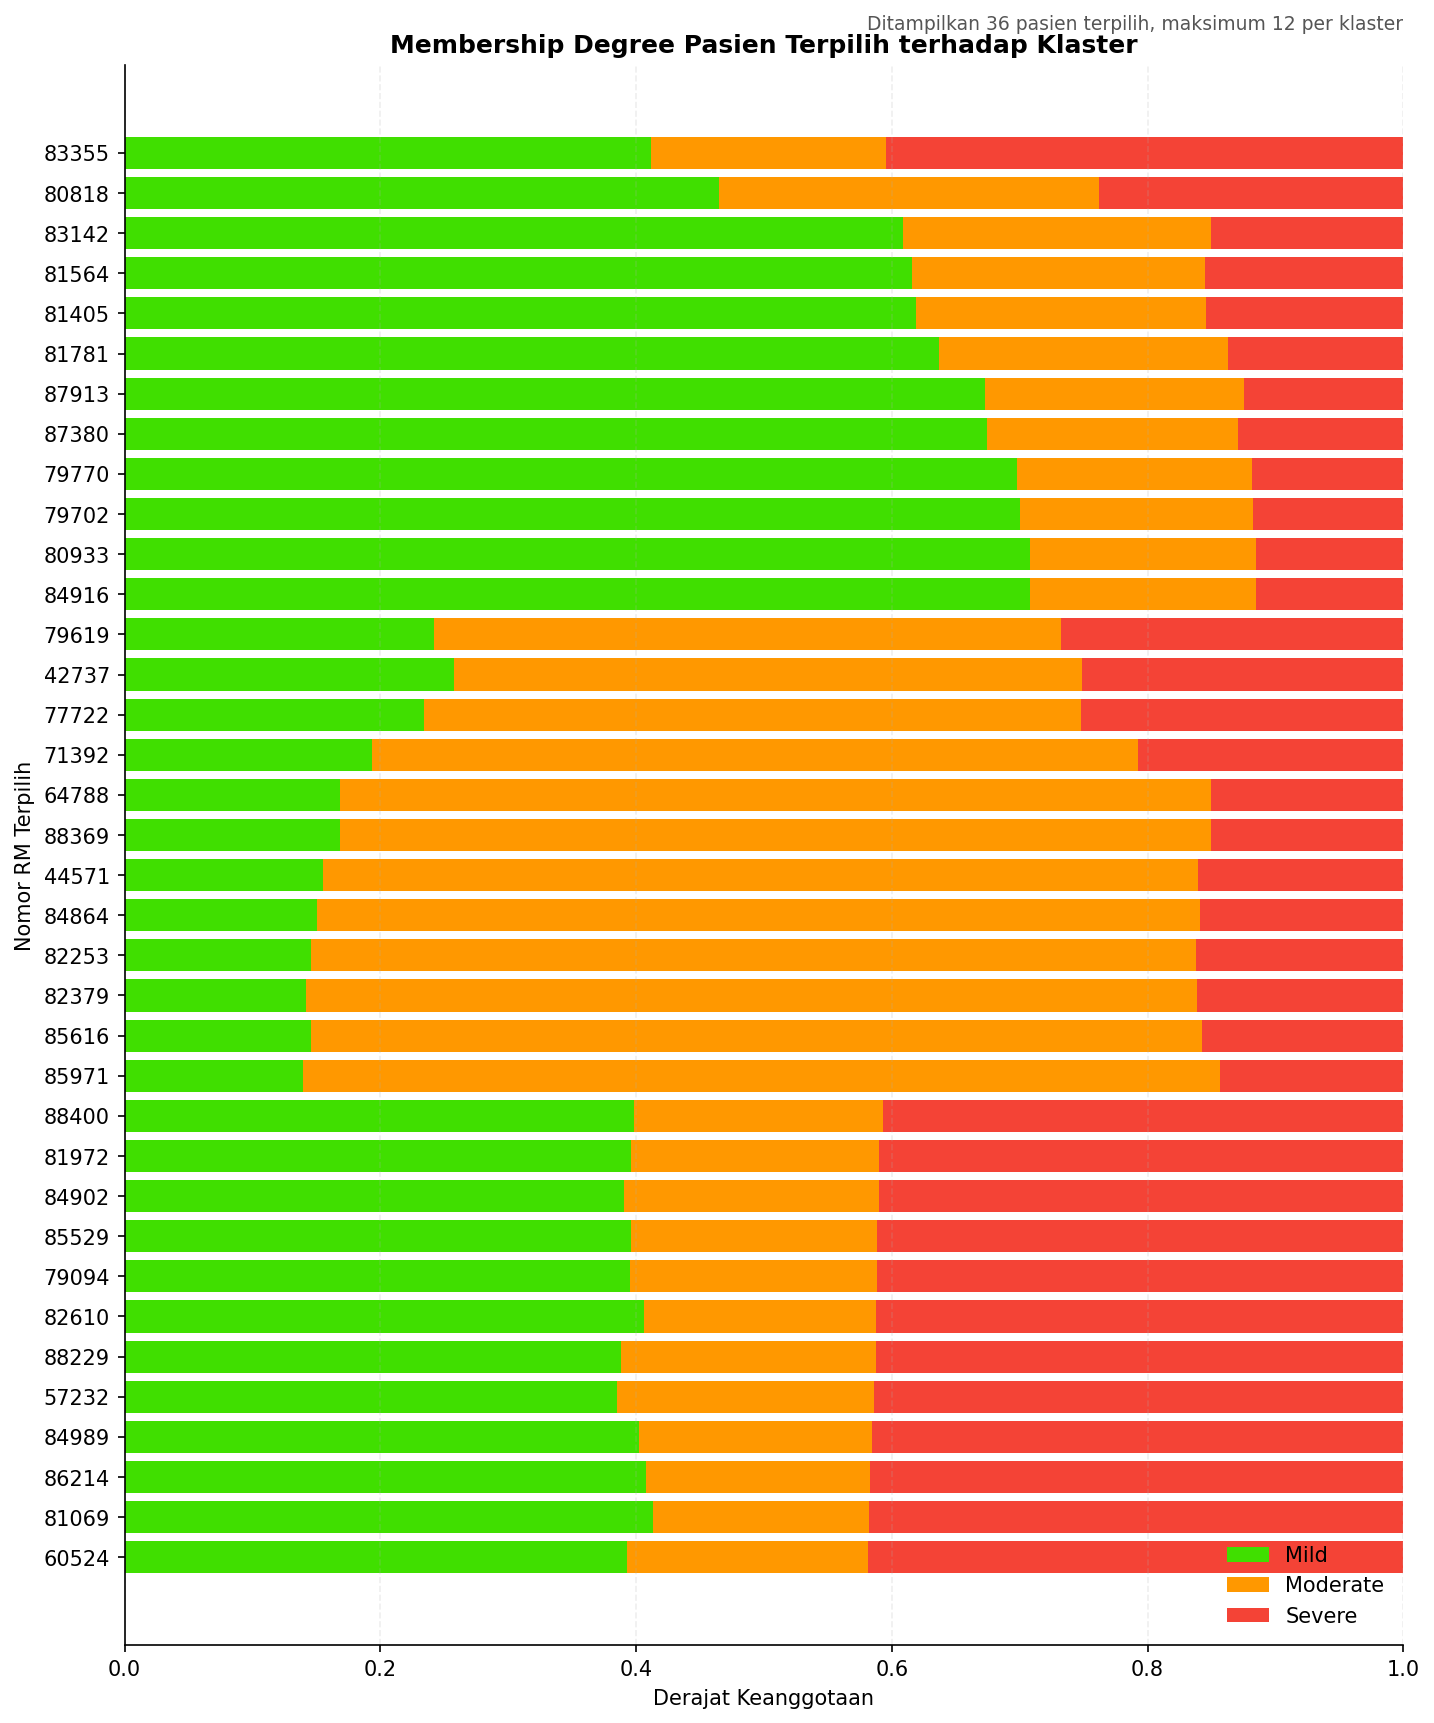

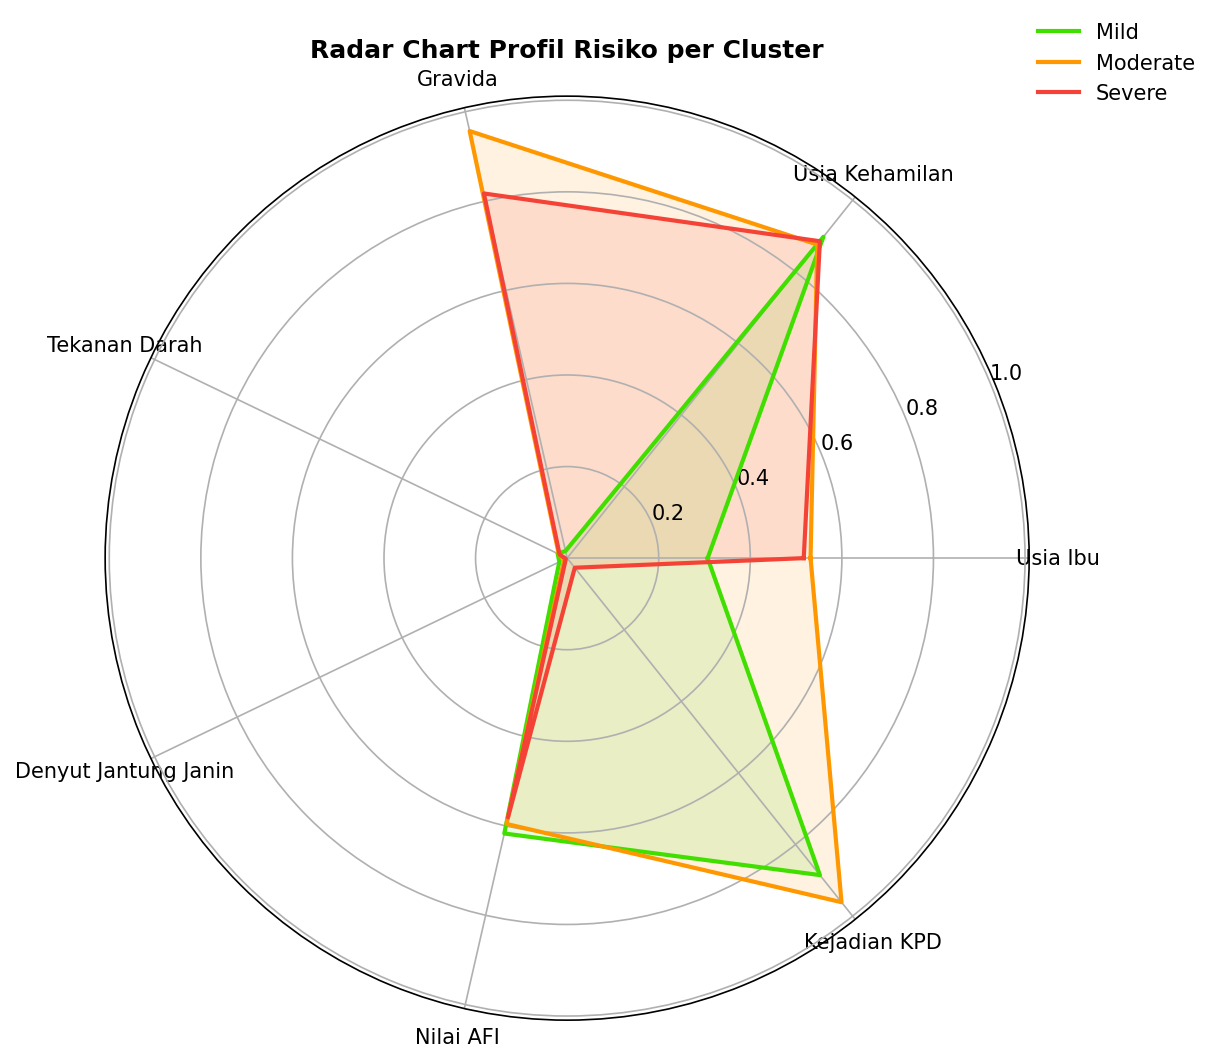

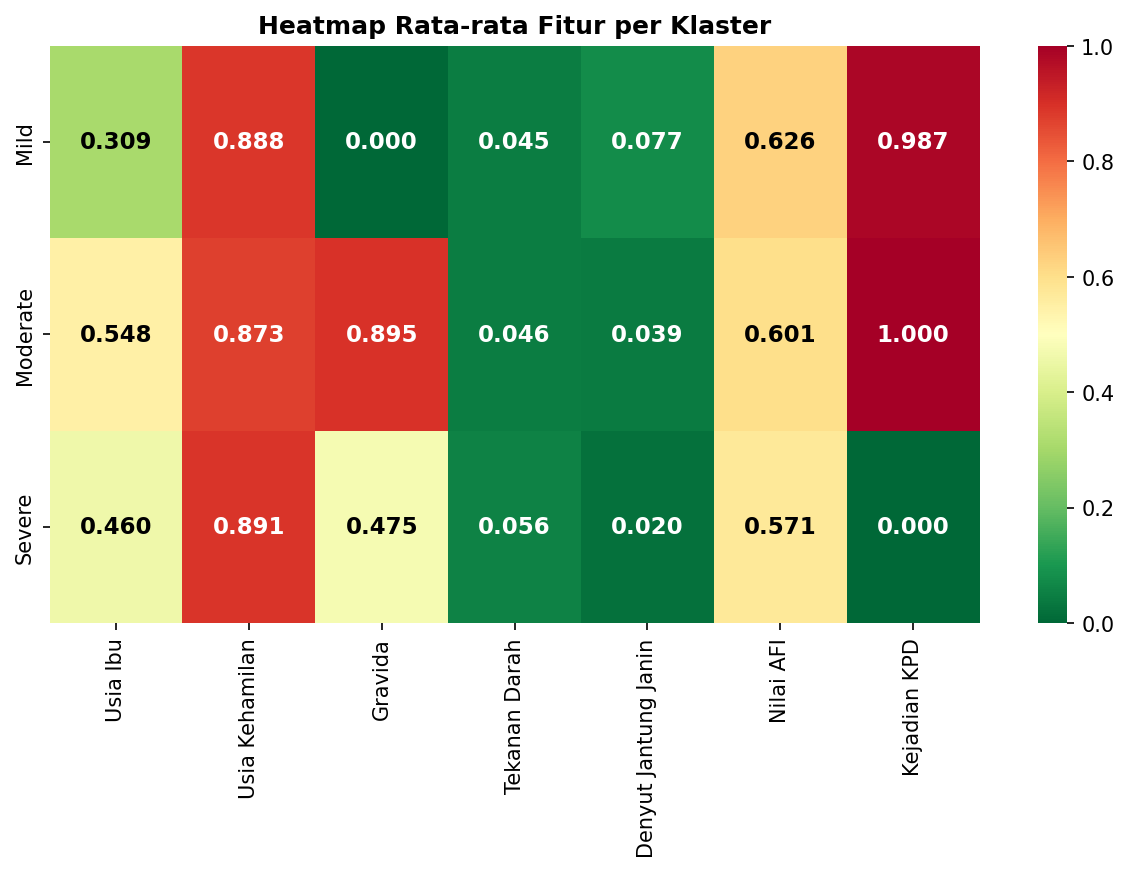

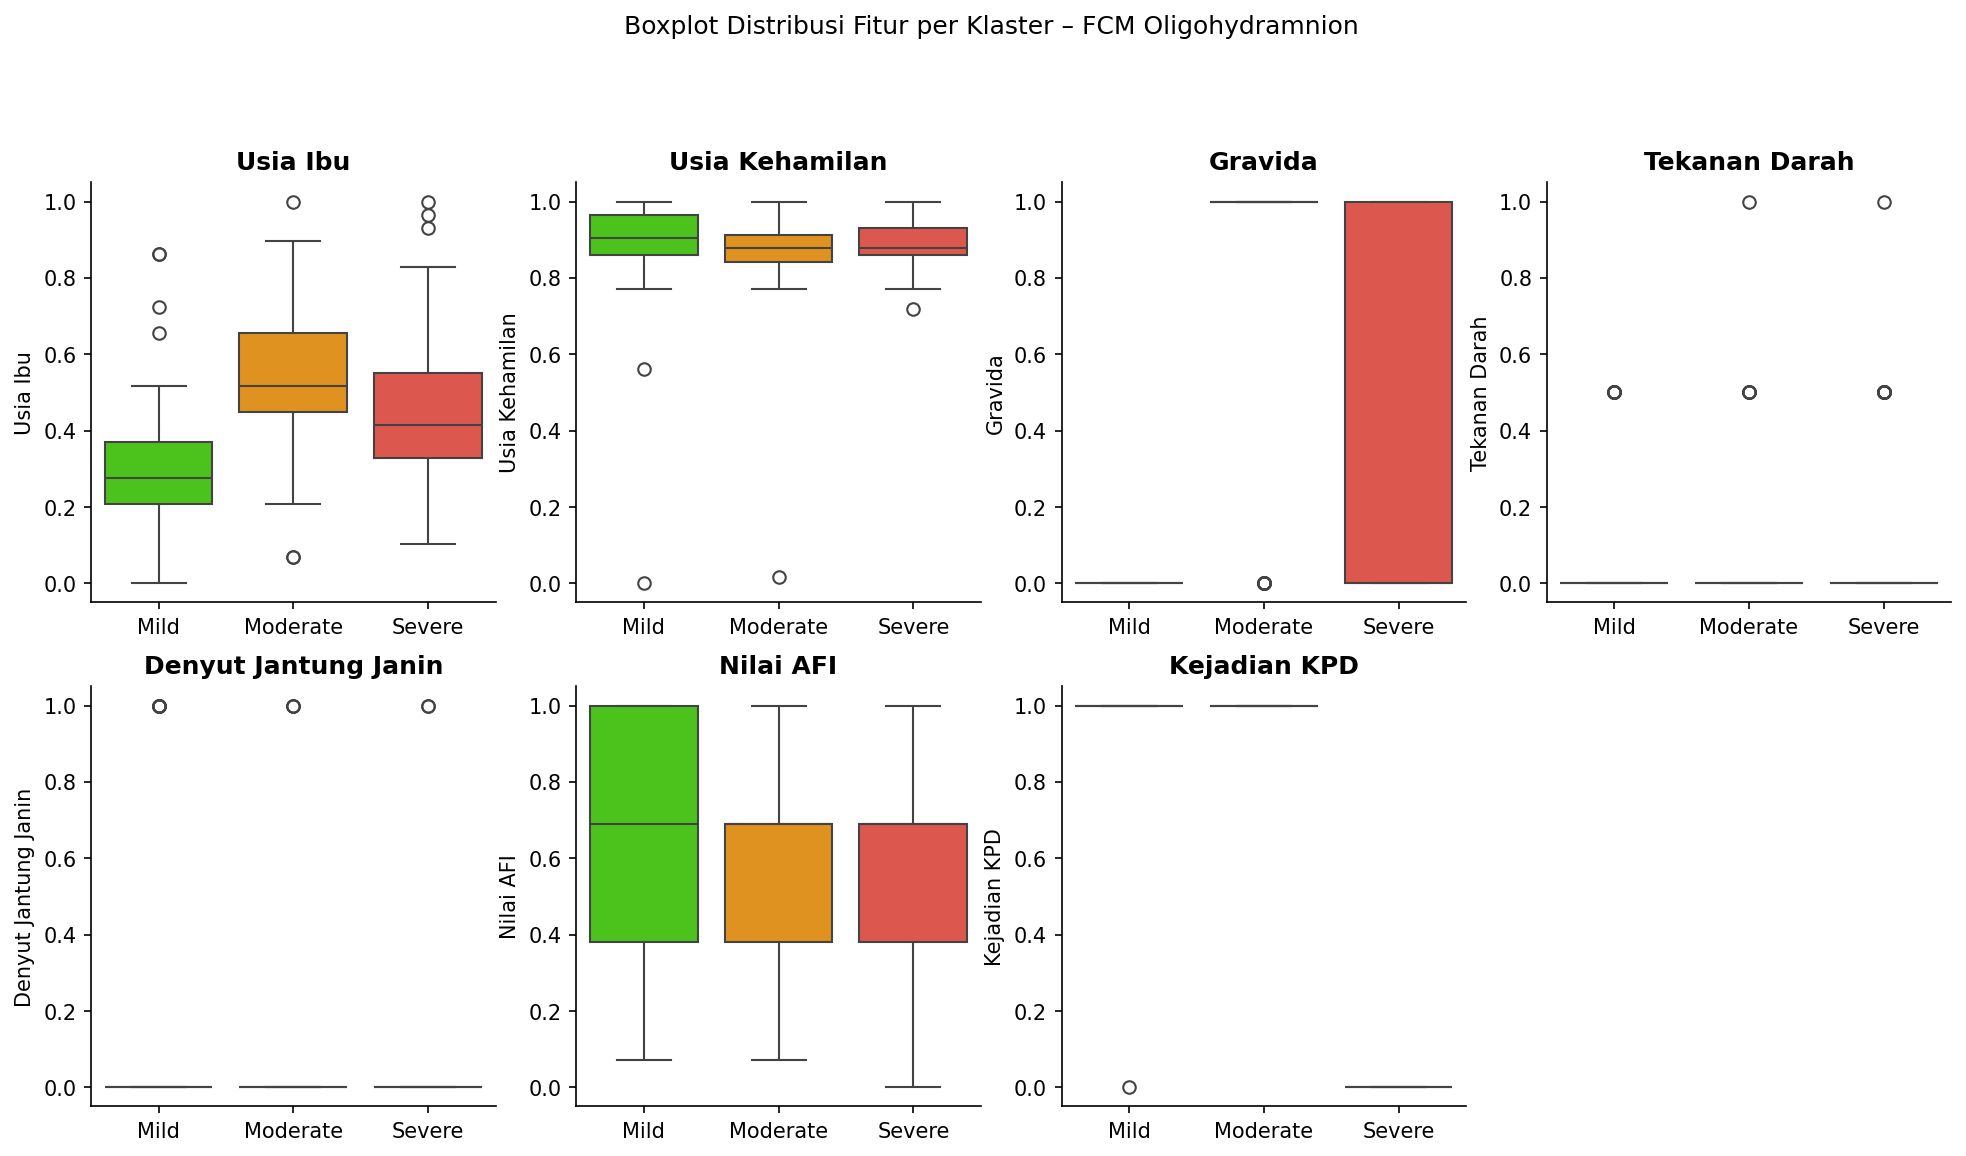

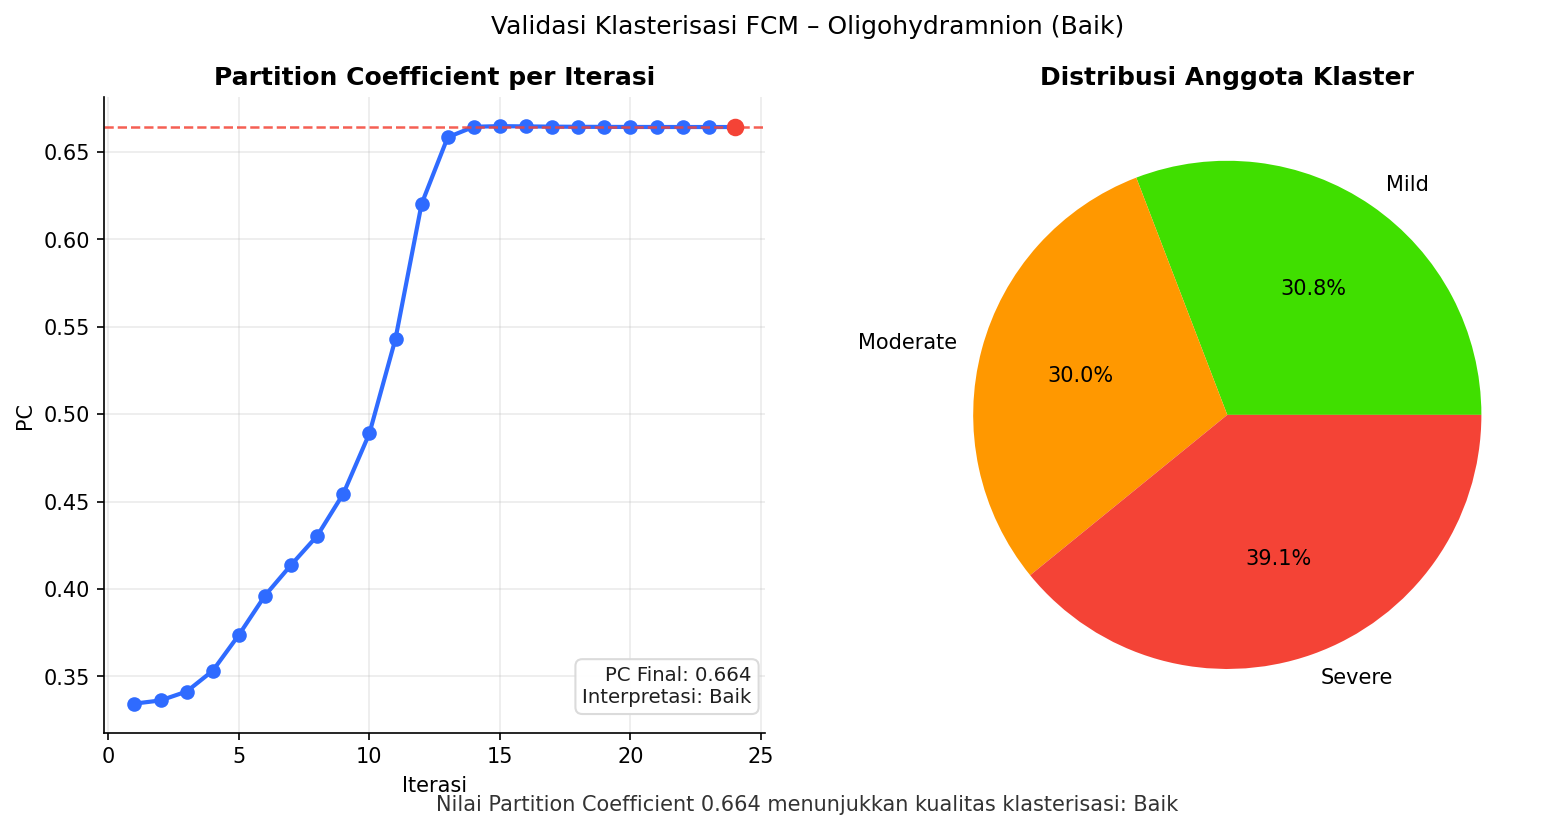

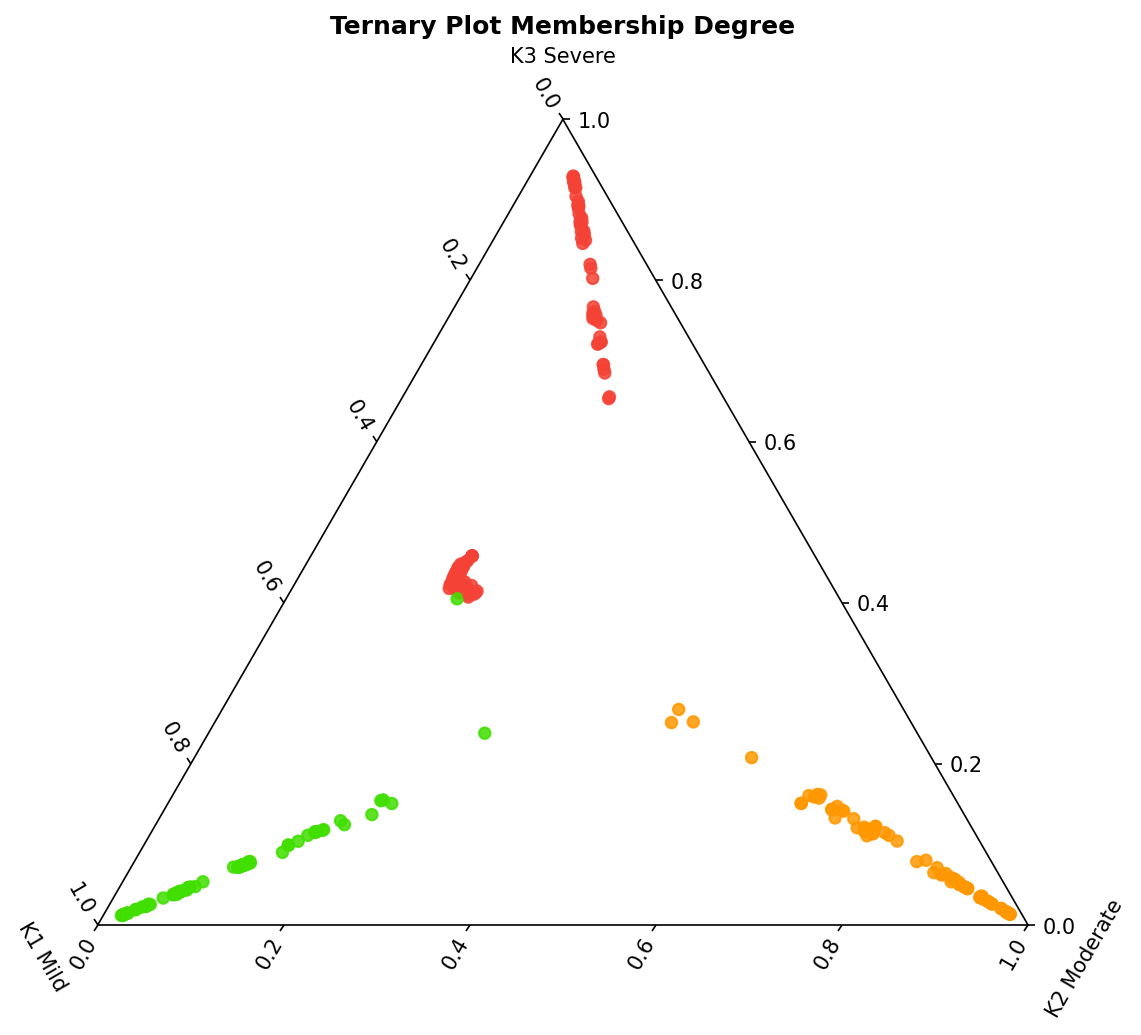

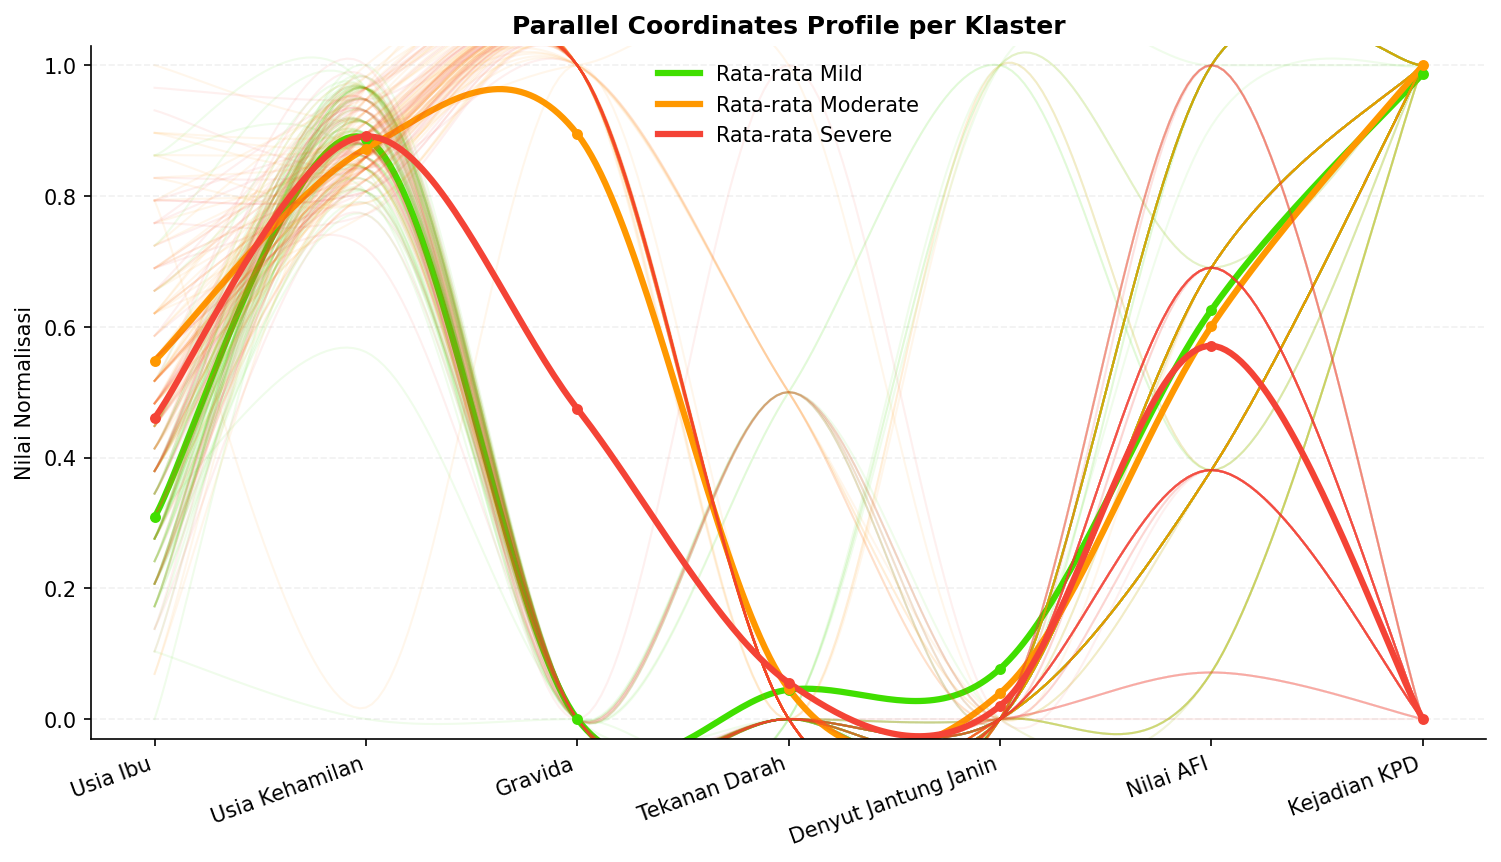

PC final        : 0.664322 (Baik)
Iterasi training: 24
Evaluasi dan visualisasi berhasil diperbarui.


,No,Nomor RM,K1,K2,K3,?1²,?2²,?3²,Hasil,Prediksi Tindakan,Tindakan Aktual,Tindakan Aktual Bersih,Prediksi Ringkas,Kesesuaian Tindakan
0,1,54121,0.043039,0.911297,0.045664,0.001852,0.830462,0.002085,Moderate,SC / SCTP,sc,sc,sc / sctp,Selaras
1,2,65046,0.048423,0.901616,0.049961,0.002345,0.812911,0.002496,Moderate,SC / SCTP,sc,sc,sc / sctp,Selaras
2,3,78533,0.050916,0.892289,0.056794,0.002592,0.796180,0.003226,Moderate,SC / SCTP,sc,sc,sc / sctp,Selaras
3,4,83531,0.900059,0.062442,0.037499,0.810106,0.003899,0.001406,Mild,"Observasi, Bed Rest, Rehidrasi, Pervaginam",sc,sc,"observasi,bed rest,rehidrasi,pervaginam",Perlu Review
4,5,79120,0.110981,0.199470,0.689549,0.012317,0.039788,0.475478,Severe,SC Cito,sc+mow,sc+mow,sc cito,Selaras


In [6]:
preprocessing_df = read_output_csv(OUTPUT_DIR / "output_preprocessing.csv")
final_df = read_output_csv(OUTPUT_DIR / "output_fcm_final.csv")
centers_df = read_output_csv(OUTPUT_DIR / "output_pusat_klaster.csv")
pc_history = json.loads((ARTIFACT_DIR / "pc_history.json").read_text(encoding="utf-8"))
training_summary = json.loads((ARTIFACT_DIR / "training_summary.json").read_text(encoding="utf-8"))

cluster_indices = np.argmax(final_df[["K1", "K2", "K3"]].to_numpy(dtype=float), axis=1)
dominant_labels = [CLUSTER_LABELS[index] for index in cluster_indices]
cluster_colors = [CLUSTER_COLORS[label] for label in dominant_labels]

centers_numeric = centers_df[FEATURE_COLUMNS].to_numpy(dtype=float)

output_eval = final_df.copy()
output_eval["Tindakan Aktual Bersih"] = output_eval["Tindakan Aktual"].fillna("").apply(clean_action_text)
output_eval["Prediksi Ringkas"] = output_eval["Prediksi Tindakan"].apply(summarize_prediction)
output_eval["Kesesuaian Tindakan"] = [
    classify_alignment(label, action)
    for label, action in zip(output_eval["Hasil"], output_eval["Tindakan Aktual"].fillna(""))
]
output_eval.to_csv(EVALUATION_DIR / "output_evaluasi_tindakan.csv", index=False, encoding="utf-8-sig")

pc_final = float(pc_history["pc_final"])
pc_label = interpret_pc(pc_final)
cluster_counts = pd.Series(dominant_labels).value_counts().reindex(CLUSTER_LABELS, fill_value=0)

fig, ax = plt.subplots(figsize=(10.5, 7))
ax.set_facecolor("#FCFCFC")

for cluster_label in CLUSTER_LABELS:
    mask = np.array(dominant_labels) == cluster_label
    x_values = preprocessing_df.loc[mask, "Nilai AFI"]
    y_values = preprocessing_df.loc[mask, "Usia Ibu"]
    ax.scatter(
        x_values,
        y_values,
        s=62,
        alpha=0.82,
        c=CLUSTER_COLORS[cluster_label],
        edgecolors="white",
        linewidths=0.8,
        label=f"{cluster_label} ({mask.sum()})",
        zorder=2,
    )

for index, cluster_label in enumerate(CLUSTER_LABELS):
    center_x = centers_numeric[index, FEATURE_COLUMNS.index("Nilai AFI")]
    center_y = centers_numeric[index, FEATURE_COLUMNS.index("Usia Ibu")]
    ax.scatter(
        center_x,
        center_y,
        marker="*",
        s=420,
        color="#1F1F1F",
        edgecolors=CLUSTER_COLORS[cluster_label],
        linewidths=2.2,
        zorder=4,
    )
    ax.annotate(
        f"C{index + 1}",
        (center_x, center_y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        color="#1F1F1F",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=CLUSTER_COLORS[cluster_label], lw=1),
        zorder=5,
    )

count_summary = "\n".join([f"{label}: {cluster_counts[label]} pasien" for label in CLUSTER_LABELS])
ax.text(
    0.985,
    0.03,
    count_summary,
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9.5,
    color="#2D2D2D",
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#D9D9D9", lw=1, alpha=0.95),
)

ax.set_title("Scatter Plot Clustering FCM – Oligohydramnion", pad=12)
ax.set_xlabel("Nilai AFI (Normalisasi)")
ax.set_ylabel("Usia Ibu (Normalisasi)")
ax.set_xlim(-0.03, 1.03)
ax.set_ylim(-0.03, 1.03)
ax.grid(alpha=0.22, linestyle="--", linewidth=0.7)
ax.legend(
    title="Klaster Dominan",
    frameon=True,
    fancybox=True,
    facecolor="white",
    edgecolor="#D9D9D9",
    loc="upper left",
)
save_matplotlib_figure(OUTPUT_DIR / "visualisasi_scatter_plot.png")

membership_plot_df = final_df.copy()
membership_plot_df["Dominan"] = dominant_labels
membership_plot_df["Membership Dominan"] = membership_plot_df[["K1", "K2", "K3"]].max(axis=1)
membership_plot_df["Ketidakpastian"] = 1 - membership_plot_df["Membership Dominan"]

membership_subset_frames = []
max_per_cluster = 12
for cluster_label in CLUSTER_LABELS:
    cluster_subset = membership_plot_df.loc[membership_plot_df["Dominan"] == cluster_label].copy()
    cluster_subset = cluster_subset.sort_values(["Ketidakpastian", "Nomor RM"], ascending=[False, True]).head(max_per_cluster)
    membership_subset_frames.append(cluster_subset)

membership_subset_df = pd.concat(membership_subset_frames, ignore_index=True)
membership_subset_df = membership_subset_df.sort_values(["Dominan", "Ketidakpastian"], ascending=[True, False]).reset_index(drop=True)

fig_height = max(7, len(membership_subset_df) * 0.38)
fig, ax = plt.subplots(figsize=(11, fig_height))
y_positions = np.arange(len(membership_subset_df))
left = np.zeros(len(membership_subset_df))
for column, cluster_label in zip(["K1", "K2", "K3"], CLUSTER_LABELS):
    values = membership_subset_df[column].to_numpy(dtype=float)
    ax.barh(y_positions, values, left=left, color=CLUSTER_COLORS[cluster_label], label=cluster_label)
    left += values

ax.set_yticks(y_positions)
ax.set_yticklabels(membership_subset_df["Nomor RM"].astype(str))
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("Derajat Keanggotaan")
ax.set_ylabel("Nomor RM Terpilih")
ax.set_title("Membership Degree Pasien Terpilih terhadap Klaster")
ax.text(
    1.0,
    1.02,
    f"Ditampilkan {len(membership_subset_df)} pasien terpilih, maksimum {max_per_cluster} per klaster",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    color="#555555",
)
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="x", alpha=0.2, linestyle="--")
save_matplotlib_figure(OUTPUT_DIR / "visualisasi_membership_degree.png")

angles = np.linspace(0, 2 * np.pi, len(FEATURE_COLUMNS), endpoint=False).tolist()
angles += angles[:1]
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "polar"})
for index, cluster_label in enumerate(CLUSTER_LABELS):
    values = centers_numeric[index].tolist()
    values += values[:1]
    ax.plot(angles, values, color=CLUSTER_COLORS[cluster_label], linewidth=2, label=cluster_label)
    ax.fill(angles, values, color=CLUSTER_COLORS[cluster_label], alpha=0.12)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(FEATURE_COLUMNS)
ax.set_title("Radar Chart Profil Risiko per Cluster")
ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1), frameon=False)
save_matplotlib_figure(OUTPUT_DIR / "visualisasi_radar_chart.png")

cluster_means = []
for cluster_label in CLUSTER_LABELS:
    mask = np.array(dominant_labels) == cluster_label
    cluster_means.append(preprocessing_df.loc[mask, FEATURE_COLUMNS].mean())
heatmap_df = pd.DataFrame(cluster_means, index=CLUSTER_LABELS)
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heatmap_df, annot=False, cmap="RdYlGn_r", vmin=0, vmax=1, ax=ax)
for row_index in range(heatmap_df.shape[0]):
    for col_index in range(heatmap_df.shape[1]):
        value = float(heatmap_df.iloc[row_index, col_index])
        text_color = "white" if value <= 0.20 or value >= 0.75 else "black"
        ax.text(
            col_index + 0.5,
            row_index + 0.5,
            f"{value:.3f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=11,
            fontweight="bold",
        )
ax.set_title("Heatmap Rata-rata Fitur per Klaster")
save_matplotlib_figure(OUTPUT_DIR / "visualisasi_heatmap.png")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
plot_df = preprocessing_df.copy()
plot_df["Klaster"] = dominant_labels
for axis, feature_name in zip(axes, FEATURE_COLUMNS):
    sns.boxplot(
        data=plot_df,
        x="Klaster",
        hue="Klaster",
        y=feature_name,
        order=CLUSTER_LABELS,
        palette=CLUSTER_COLORS,
        legend=False,
        ax=axis,
    )
    axis.set_title(feature_name)
    axis.set_xlabel("")
axes[-1].axis("off")
fig.suptitle("Boxplot Distribusi Fitur per Klaster – FCM Oligohydramnion", y=1.02)
save_matplotlib_figure(OUTPUT_DIR / "visualisasi_boxplot.png")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.5))
iteration_axis = range(1, len(pc_history["pc_history"]) + 1)
axes[0].plot(iteration_axis, pc_history["pc_history"], marker="o", color="#2F6BFF", linewidth=2)
axes[0].axhline(pc_final, color="#F44336", linestyle="--", linewidth=1.2, alpha=0.85)
axes[0].scatter(len(pc_history["pc_history"]), pc_final, color="#F44336", s=55, zorder=3)
axes[0].set_title("Partition Coefficient per Iterasi")
axes[0].set_xlabel("Iterasi")
axes[0].set_ylabel("PC")
axes[0].grid(alpha=0.25)
axes[0].text(
    0.98,
    0.04,
    f"PC Final: {pc_final:.3f}\nInterpretasi: {pc_label}",
    transform=axes[0].transAxes,
    ha="right",
    va="bottom",
    fontsize=9.5,
    color="#1F1F1F",
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#D9D9D9", lw=1, alpha=0.95),
)
axes[1].pie(
    cluster_counts.values,
    labels=cluster_counts.index,
    colors=[CLUSTER_COLORS[label] for label in cluster_counts.index],
    autopct="%1.1f%%",
)
axes[1].set_title("Distribusi Anggota Klaster")
fig.suptitle(f"Validasi Klasterisasi FCM – Oligohydramnion ({pc_label})")
fig.text(
    0.5,
    0.01,
    f"Nilai Partition Coefficient {pc_final:.3f} menunjukkan kualitas klasterisasi: {pc_label}",
    ha="center",
    va="bottom",
    fontsize=10,
    color="#333333",
)
save_matplotlib_figure(OUTPUT_DIR / "visualisasi_validasi_pc.png")

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(projection="ternary")
ax.scatter(
    final_df["K3"],
    final_df["K1"],
    final_df["K2"],
    c=cluster_colors,
    s=30,
    alpha=0.85,
)
ax.set_tlabel("K3 Severe")
ax.set_llabel("K1 Mild")
ax.set_rlabel("K2 Moderate")
ax.set_title("Ternary Plot Membership Degree")
save_matplotlib_figure(OUTPUT_DIR / "visualisasi_ternary_plot.png")

fig, ax = plt.subplots(figsize=(12, 6))
feature_positions = np.arange(len(FEATURE_COLUMNS), dtype=float)
for cluster_label in CLUSTER_LABELS:
    mask = np.array(dominant_labels) == cluster_label
    cluster_data = preprocessing_df.loc[mask, FEATURE_COLUMNS].to_numpy(dtype=float)
    for row in cluster_data[:80]:
        smooth_x, smooth_y = catmull_rom_smooth(feature_positions, row, samples_per_segment=35)
        ax.plot(smooth_x, smooth_y, color=CLUSTER_COLORS[cluster_label], alpha=0.08, linewidth=1)
    if len(cluster_data):
        cluster_mean = cluster_data.mean(axis=0)
        smooth_x, smooth_y = catmull_rom_smooth(feature_positions, cluster_mean, samples_per_segment=45)
        ax.plot(smooth_x, smooth_y, color=CLUSTER_COLORS[cluster_label], linewidth=3, label=f"Rata-rata {cluster_label}")
        ax.scatter(feature_positions, cluster_mean, color=CLUSTER_COLORS[cluster_label], s=18, zorder=3)
ax.set_xticks(feature_positions)
ax.set_xticklabels(FEATURE_COLUMNS, rotation=20, ha="right")
ax.set_ylim(-0.03, 1.03)
ax.set_ylabel("Nilai Normalisasi")
ax.set_title("Parallel Coordinates Profile per Klaster")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.18, linestyle="--")
save_matplotlib_figure(OUTPUT_DIR / "visualisasi_parallel_coordinates_smooth.png")

prediksi_categories = output_eval["Prediksi Tindakan"].fillna("-")
actual_categories = output_eval["Tindakan Aktual Bersih"].replace("", "tanpa data")
source_labels = [f"Klaster: {label}" for label in output_eval["Hasil"]]
unique_nodes = list(dict.fromkeys(list(source_labels) + list(prediksi_categories) + list(actual_categories)))
node_index = {label: idx for idx, label in enumerate(unique_nodes)}

first_links = output_eval.groupby(["Hasil", "Prediksi Tindakan"]).size().reset_index(name="value")
second_links = output_eval.groupby(["Prediksi Tindakan", "Tindakan Aktual Bersih"]).size().reset_index(name="value")
link_sources = []
link_targets = []
link_values = []
for _, row in first_links.iterrows():
    link_sources.append(node_index[f"Klaster: {row['Hasil']}"])
    link_targets.append(node_index[row["Prediksi Tindakan"]])
    link_values.append(int(row["value"]))
for _, row in second_links.iterrows():
    label_actual = row["Tindakan Aktual Bersih"] if row["Tindakan Aktual Bersih"] else "tanpa data"
    link_sources.append(node_index[row["Prediksi Tindakan"]])
    link_targets.append(node_index[label_actual])
    link_values.append(int(row["value"]))

fig_sankey = go.Figure(
    data=[
        go.Sankey(
            node=dict(label=unique_nodes, pad=15, thickness=18),
            link=dict(source=link_sources, target=link_targets, value=link_values),
        )
    ]
)
fig_sankey.update_layout(title="Sankey Prediksi dan Tindakan", font_size=11)
fig_sankey.write_html(OUTPUT_DIR / "visualisasi_sankey_tindakan.html", include_plotlyjs="cdn")
show_plotly_figure(fig_sankey)

sunburst_df = output_eval.copy()
sunburst_df["Tindakan Aktual Bersih"] = sunburst_df["Tindakan Aktual Bersih"].replace("", "tanpa data")
fig_sunburst = px.sunburst(
    sunburst_df,
    path=["Hasil", "Prediksi Tindakan", "Kesesuaian Tindakan"],
    color="Hasil",
    color_discrete_map=CLUSTER_COLORS,
)
fig_sunburst.update_layout(title="Sunburst Ringkasan Tindakan")
fig_sunburst.write_html(OUTPUT_DIR / "visualisasi_sunburst_tindakan.html", include_plotlyjs="cdn")
show_plotly_figure(fig_sunburst)

scatter3d_df = preprocessing_df.copy()
scatter3d_df["Klaster"] = dominant_labels
fig_3d = px.scatter_3d(
    scatter3d_df,
    x="Nilai AFI",
    y="Usia Ibu",
    z="Usia Kehamilan",
    color="Klaster",
    color_discrete_map=CLUSTER_COLORS,
    title="3D Scatter Plot Clustering FCM",
)
fig_3d.write_html(OUTPUT_DIR / "visualisasi_3d_scatter.html", include_plotlyjs="cdn")
show_plotly_figure(fig_3d)

evaluation_summary = {
    "pc_final": pc_final,
    "pc_interpretasi": pc_label,
    "iterations_run": int(training_summary["iterations_run"]),
    "cluster_counts": {key: int(value) for key, value in cluster_counts.to_dict().items()},
    "visualizations": {
        "scatter": str((OUTPUT_DIR / "visualisasi_scatter_plot.png").resolve()),
        "membership": str((OUTPUT_DIR / "visualisasi_membership_degree.png").resolve()),
        "radar": str((OUTPUT_DIR / "visualisasi_radar_chart.png").resolve()),
        "heatmap": str((OUTPUT_DIR / "visualisasi_heatmap.png").resolve()),
        "boxplot": str((OUTPUT_DIR / "visualisasi_boxplot.png").resolve()),
        "pc_validation": str((OUTPUT_DIR / "visualisasi_validasi_pc.png").resolve()),
        "ternary": str((OUTPUT_DIR / "visualisasi_ternary_plot.png").resolve()),
        "parallel_coords": str((OUTPUT_DIR / "visualisasi_parallel_coordinates_smooth.png").resolve()),
        "sankey": str((OUTPUT_DIR / "visualisasi_sankey_tindakan.html").resolve()),
        "sunburst": str((OUTPUT_DIR / "visualisasi_sunburst_tindakan.html").resolve()),
        "scatter_3d": str((OUTPUT_DIR / "visualisasi_3d_scatter.html").resolve()),
    },
    "evaluation_output": str((EVALUATION_DIR / "output_evaluasi_tindakan.csv").resolve()),
}
(ARTIFACT_DIR / "evaluation_summary.json").write_text(json.dumps(evaluation_summary, indent=2), encoding="utf-8")

print(f"PC final        : {pc_final:.6f} ({pc_label})")
print(f"Iterasi training: {training_summary['iterations_run']}")
print("Evaluasi dan visualisasi berhasil diperbarui.")
output_eval.head()